# Análisis Exploratorio y Rendimiento de Criptomonedas (2021-2024)

En este notebook vamos a analizar el comportamiento de un portafolio de criptomonedas, comparando sus métricas clave como el Retorno de Inversión (ROI), la volatilidad (Coeficiente de Variación), resiliencia ante caídas y estacionalidad. 

## Configurar y cargar datos
Primero importamos las librerías necesarias para el análisis de datos y la visualización. Luego unimos los archivos CSV (uno por cada cripto) en un único conjunto de datos y realizamos una limpieza básica.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob
import seaborn as sns
from scipy.stats import linregress
import os

# Configuración estética de Seaborn
sns.set_theme(style="whitegrid")

# Ruta a la carpeta con los CSV
ruta = 'archive'
archivos_csv = glob.glob(os.path.join(ruta, "*.csv"))

lista_dataframes = []

# Cargar cada archivo CSV y extraer el símbolo de la moneda
for archivo in archivos_csv:
    df_temporal = pd.read_csv(archivo)
    nombre_archivo = os.path.basename(archivo)
    simbolo = nombre_archivo.split('-')[0] 
    df_temporal['Simbolo'] = simbolo
    lista_dataframes.append(df_temporal)

# Concatenar todos los dataframes
df_completo = pd.concat(lista_dataframes, ignore_index=True)

# Vista previa del dataframe completo
print(df_completo)

                            Date      Open      High       Low     Close  \
0      2017-11-09 00:00:00+00:00  0.025160  0.035060  0.025006  0.032053   
1      2017-11-10 00:00:00+00:00  0.032219  0.033348  0.026451  0.027119   
2      2017-11-11 00:00:00+00:00  0.026891  0.029659  0.025684  0.027437   
3      2017-11-12 00:00:00+00:00  0.027480  0.027952  0.022591  0.023977   
4      2017-11-13 00:00:00+00:00  0.024364  0.026300  0.023495  0.025808   
...                          ...       ...       ...       ...       ...   
24568  2024-11-25 00:00:00+00:00  1.432413  1.535923  1.364327  1.415423   
24569  2024-11-26 00:00:00+00:00  1.415367  1.456542  1.294805  1.401323   
24570  2024-11-27 00:00:00+00:00  1.401312  1.518370  1.357346  1.472812   
24571  2024-11-28 00:00:00+00:00  1.472847  1.542370  1.434183  1.541343   
24572  2024-11-29 00:00:00+00:00  1.541334  1.811531  1.527908  1.796731   

             Volume Simbolo  Dividends  Stock Splits  
0      1.871620e+07     ADA     

### Limpieza y Filtrado
Los datos sacados de Yahoo Finance suelen incluyen columnas de Dividends y Stock Splits que no aplican ni tienen relevancia para el análisis, así que serán eliminadas. Además, filtraremos el dataset para enfocarnos exclusivamente en el ciclo del mercado desde el 1 de enero de 2021.

In [ ]:
# Convertir 'Date' a datetime y quitar la zona horaria para estandarizar
df_completo['Date'] = pd.to_datetime(df_completo['Date']).dt.tz_localize(None)

# Eliminar columnas innecesarias
columnas_a_eliminar = ['Dividends', 'Stock Splits']
df_completo = df_completo.drop(columns=[col for col in columnas_a_eliminar if col in df_completo.columns])

# Ordenar por Símbolo y Fecha
df_completo = df_completo.sort_values(by=['Simbolo', 'Date']).reset_index(drop=True)

# Filtramos desde el 1 de enero de 2021
fecha_inicio = '2021-01-01'
df_filtrado = df_completo[df_completo['Date'] >= fecha_inicio].copy()

# Comprobaciones
print("Información del Dataset Completo:")
print(df_completo.info())
print("\nRango de datos filtrados:")
print(f"Desde: {df_filtrado['Date'].min()} hasta {df_filtrado['Date'].max()}")

Información del Dataset Completo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24573 entries, 0 to 24572
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     24573 non-null  datetime64[ns]
 1   Open     24573 non-null  float64       
 2   High     24573 non-null  float64       
 3   Low      24573 non-null  float64       
 4   Close    24573 non-null  float64       
 5   Volume   24573 non-null  float64       
 6   Simbolo  24573 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 1.3+ MB
None

Rango de datos filtrados:
Desde: 2021-01-01 00:00:00 hasta 2024-11-29 00:00:00


### Resultados de la Carga y Limpieza
El conjunto de datos consolidado contiene **24,573 registros** y 7 columnas fundamentales (`Date`, `Open`, `High`, `Low`, `Close`, `Volume`, `Simbolo`). 

El dataset ahora está completamente limpio, **sin valores nulos**, lo que garantiza la integridad de los siguientes cálculos. Luego de aplicar el filtro temporal, nuestro análisis se centrará en el período comprendido entre el **1 de enero de 2021 y el 29 de noviembre de 2024**.

## Análisis de Rentabilidad (ROI) y Volatilidad (CV)

Ahora evaluaremos el desempeño general de cada criptomoneda a lo largo de los 4 años seleccionados. Utilizaremos dos métricas fundamentales:

1. **Retorno de Inversión (ROI):** Mide la rentabilidad porcentual de cada activo desde el primer día hasta el último día del período analizado.
2. **Coeficiente de Variación (CV):** Actúa como métrica de riesgo o volatilidad, calculando la dispersión relativa de los precios (Desviación Estándar / Media). Un CV más alto indica que el precio de la moneda ha experimentado fluctuaciones mucho más extremas.

/tmp/ipykernel_9995/1112603968.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_roi = df_filtrado.groupby('Simbolo').apply(calcular_roi).reset_index(name='ROI (%)')
/tmp/ipykernel_9995/1112603968.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Simbolo', y='ROI (%)', data=df_roi, palette='magma', ax=axes[0])


--- Criptomonedas más rentables (ROI 2021-2024) ---
  Simbolo       ROI (%)
0     SOL  13121.410798
1    DOGE   7390.571803
2     BNB   1627.501852
3     XRP    656.696741
4     ADA    514.119233
5   STETH    397.487125
6     ETH    392.011778
7     BTC    231.793484
8    USDC      0.004602
9    USDT     -0.154711


--- Criptomonedas más volátiles (CV 2021-2024) ---
  Simbolo     CV (%)
0     SOL  83.248487
1     ADA  77.080600
2    DOGE  69.253026
3     XRP  42.857653
4     BTC  41.226942
5     BNB  38.795148
6   STETH  36.625037
7     ETH  36.293248
8    USDC   0.089569
9    USDT   0.075201


/tmp/ipykernel_9995/1112603968.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Simbolo', y='CV (%)', data=df_volatilidad, palette='viridis', ax=axes[1])


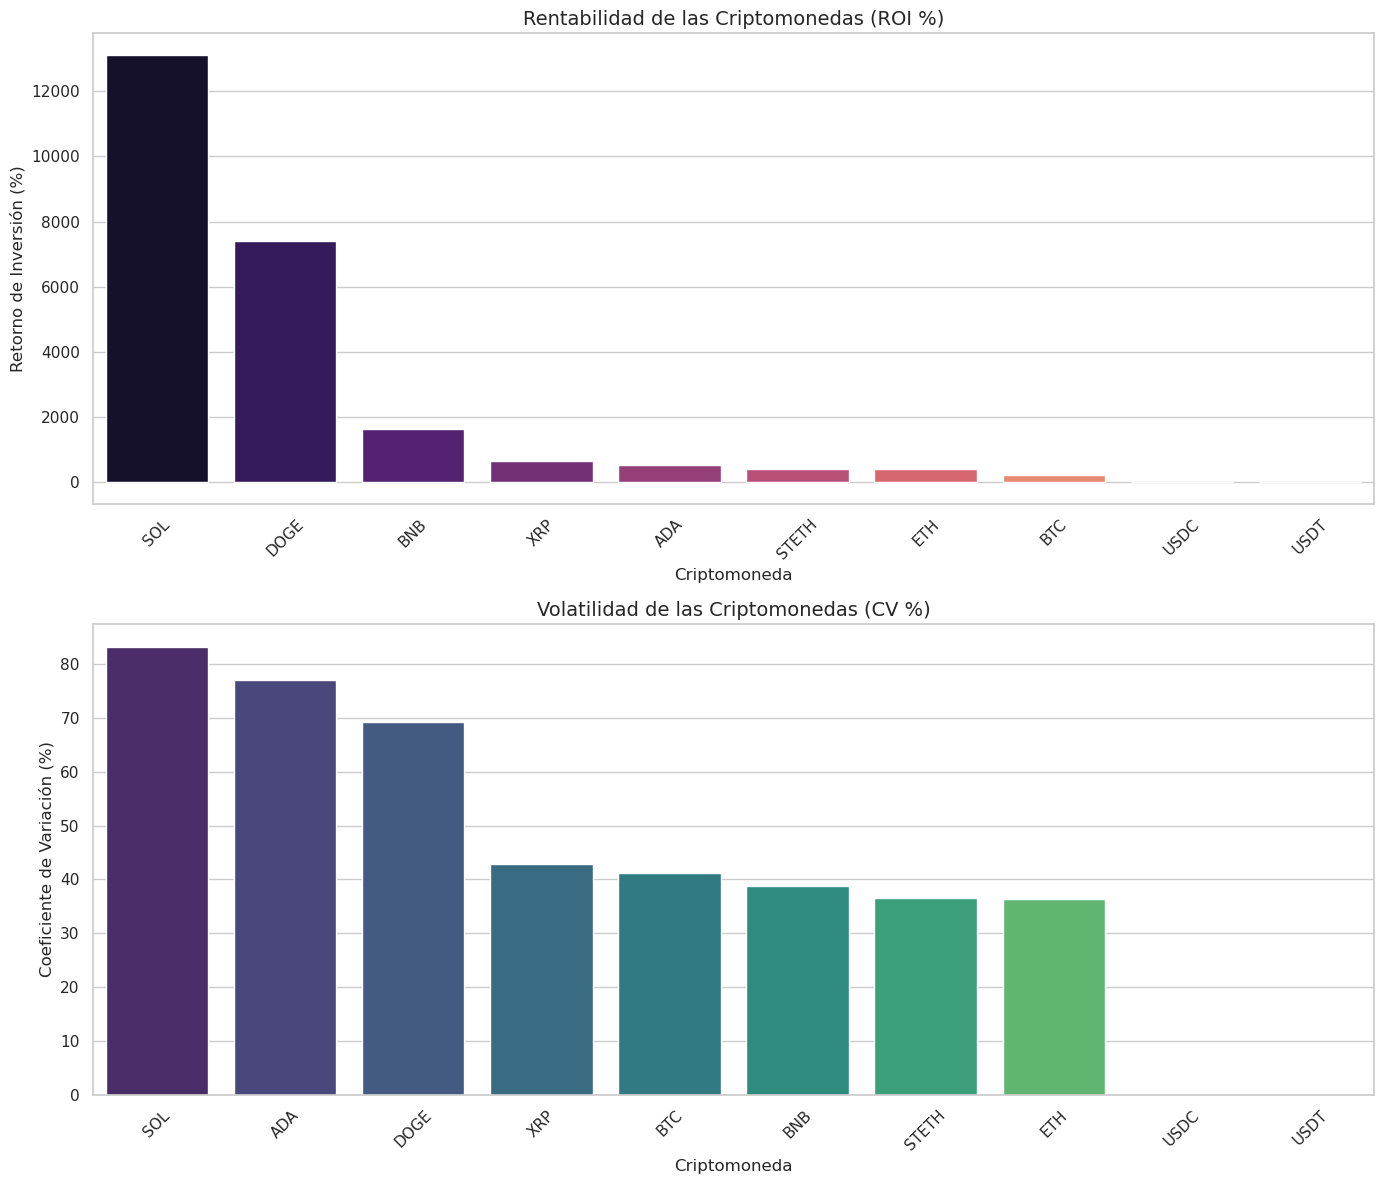

In [4]:
# --- 1. Retorno de Inversión (ROI) ---
def calcular_roi(grupo):
    precio_inicial = grupo['Close'].iloc[0]  # Primer precio del período
    precio_final = grupo['Close'].iloc[-1]   # Último precio del período
    roi = ((precio_final - precio_inicial) / precio_inicial) * 100
    return roi

# Agrupamos por criptomoneda y calculamos el ROI
df_roi = df_filtrado.groupby('Simbolo').apply(calcular_roi).reset_index(name='ROI (%)')
df_roi = df_roi.sort_values(by='ROI (%)', ascending=False).reset_index(drop=True)

print("--- Criptomonedas más rentables (ROI 2021-2024) ---")
print(df_roi.head(10)) # Mostramos el top 10 para no saturar la salida
print("\n")

# --- 2. Volatilidad (Coeficiente de Variación - CV) ---
df_volatilidad = df_filtrado.groupby('Simbolo')['Close'].agg(['mean', 'std']).reset_index()

# Aplicamos la fórmula del CV: (Desviación Estándar / Media) * 100
df_volatilidad['CV (%)'] = (df_volatilidad['std'] / df_volatilidad['mean']) * 100
df_volatilidad = df_volatilidad.sort_values(by='CV (%)', ascending=False).reset_index(drop=True)

print("--- Criptomonedas más volátiles (CV 2021-2024) ---")
print(df_volatilidad[['Simbolo', 'CV (%)']].head(10))

# --- 3. Visualizaciones ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico de Rentabilidad
sns.barplot(x='Simbolo', y='ROI (%)', data=df_roi, palette='magma', ax=axes[0])
axes[0].set_title('Rentabilidad de las Criptomonedas (ROI %)', fontsize=14)
axes[0].set_xlabel('Criptomoneda', fontsize=12)
axes[0].set_ylabel('Retorno de Inversión (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de Volatilidad
sns.barplot(x='Simbolo', y='CV (%)', data=df_volatilidad, palette='viridis', ax=axes[1])
axes[1].set_title('Volatilidad de las Criptomonedas (CV %)', fontsize=14)
axes[1].set_xlabel('Criptomoneda', fontsize=12)
axes[1].set_ylabel('Coeficiente de Variación (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Conclusiones de Rentabilidad y Volatilidad
Al analizar los gráficos y los datos generados, podemos observar dinámicas claras en el comportamiento de estos activos:

* **Altos retornos, alta volatilidad:** Solana (SOL) lidera la rentabilidad con un ROI cercano al **13,121%**. Sin embargo, este enorme crecimiento viene acompañado del mayor nivel de riesgo del portafolio, teniendo el Coeficiente de Variación más alto (**83.2%**).
* **El fenómeno memecoin:** Dogecoin (DOGE) muestra un rendimiento superior al **7,390%**, pero también se posiciona como el tercer activo más volátil (**69.2%**).
* **Madurez en las líderes:** Bitcoin (BTC) y Ethereum (ETH) presentan retornos mucho más conservadores dentro de este grupo (**231%** y **392%** respectivamente), pero lo compensan siendo de los criptoactivos menos volátiles del portafolio.
* **El rol de las Stablecoins:** USDC y USDT mantienen un ROI y CV prácticamente nulos, cumpliendo perfectamente su función teórica de refugio de valor y paridad con el dólar.

## Relación entre Riesgo y Recompensa

En finanzas tradicionales, se asume que para obtener mayores rendimientos es necesario asumir un mayor riesgo. En esta sección, calcularemos la correlación matemática entre el ROI y el CV para comprobar si esta premisa se cumple de manera estricta en el mercado de las criptomonedas durante el período analizado. Utilizaremos un diagrama de dispersión para visualizar esta relación.

Correlación de Pearson entre ROI y CV: 0.66



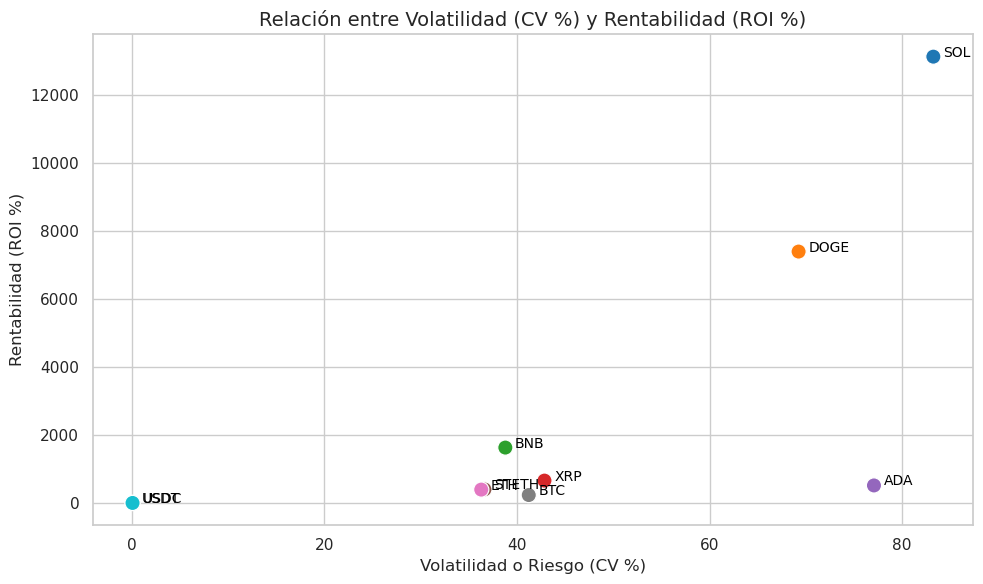

In [5]:
# Unificar datos para el análisis
df_analisis = pd.merge(df_roi, df_volatilidad[['Simbolo', 'CV (%)']], on='Simbolo')

# Calcular correlación de Pearson
correlacion = df_analisis['ROI (%)'].corr(df_analisis['CV (%)'])
print(f"Correlación de Pearson entre ROI y CV: {correlacion:.2f}\n")

# Graficar la relación
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CV (%)', y='ROI (%)', data=df_analisis, hue='Simbolo', palette='tab10', s=120, legend=False)

# Añadir etiquetas de texto a cada punto para identificar fácilmente las monedas
for i in range(df_analisis.shape[0]):
    plt.text(x=df_analisis['CV (%)'][i] + 1, 
             y=df_analisis['ROI (%)'][i], 
             s=df_analisis['Simbolo'][i], 
             fontdict=dict(color='black', size=10))

plt.title('Relación entre Volatilidad (CV %) y Rentabilidad (ROI %)', fontsize=14)
plt.xlabel('Volatilidad o Riesgo (CV %)', fontsize=12)
plt.ylabel('Rentabilidad (ROI %)', fontsize=12)
plt.tight_layout()
plt.show()

### Conclusiones sobre Riesgo y Recompensa

El cálculo matemático da una **Correlación de Pearson de 0.66**. Este valor indica una correlación positiva débil. En términos prácticos, la premisa financiera se cumple en este portafolio: existe una ligera tendencia de que a mayor riesgo, mayor ganancia.

El diagrama de dispersión nos muestra:

1. **Riesgo Nulo / Retorno Nulo:** Las stablecoins (USDT, USDC) se agrupan en el origen (0,0).
2. **El Sweet Spot Institucional:** Monedas como BTC, ETH, STETH y BNB forman un clúster. Ofrecen retornos considerables pero mantienen la volatilidad en el rango más bajo de los activos variables (entre 35% y 45%).
3. **Alto Riesgo / Retorno Excepcional:** SOL y DOGE se escapan en la gráfica hacia la esquina superior derecha. 
4. **La Anomalía:** Cardano (ADA) es un caso de estudio interesante. A pesar de tener una volatilidad altísima (similar a la de SOL y DOGE), sus retornos están estancados en el nivel del clúster conservador (BTC/ETH). En este período, el inversor de ADA asumió mucho riesgo sin la recompensa proporcional.

## El Efecto Arrastre de Bitcoin

En el ecosistema cripto existe la creencia generalizada de que Bitcoin mueve el mercado. Cuando BTC sube o baja, las altcoins (criptomonedas que no son bitcoin) tienden a seguirlo, a veces de forma inmediata y a veces con un ligero retraso. 

Para comprobar esto hacemos un análisis de **Correlación Cruzada**. En lugar de usar los precios absolutos, usaremos los retornos diarios (la variación porcentual diaria), ya que los precios son series no estacionarias que pueden arrojar correlaciones falsas.

Calcularemos cómo se correlaciona el retorno diario de BTC hoy, con el retorno de las altcoins el mismo día (Delay 0), al día siguiente (Delay 1), dos días después (Delay 2) y tres días después (Delay 3).

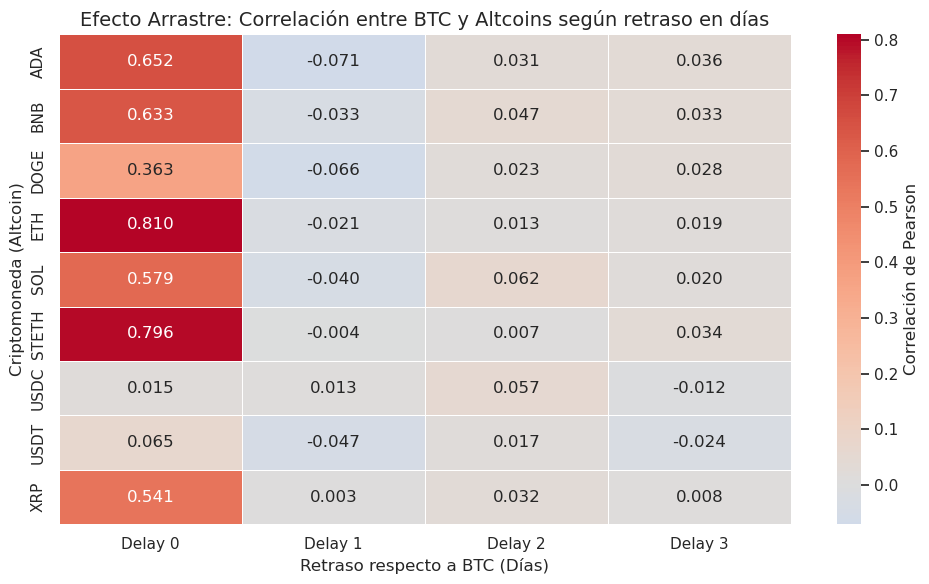

In [ ]:
# Pivotar la tabla
df_pivot = df_filtrado.pivot(index='Date', columns='Simbolo', values='Close')

# Calcular retornos diarios (%)
df_retornos = df_pivot.pct_change().dropna()

# Definir los días de delay
delays = [0, 1, 2, 3]

resultados_correlacion = {}

# Calcular la correlación desfasada
for cripto in df_retornos.columns:
    if cripto == 'BTC': # Excluimos BTC de compararse a sí mismo
        continue
        
    correlaciones_cripto = {}
    for delay in delays:
        # Desplazar la serie temporal de la altcoin
        serie_desfasada = df_retornos[cripto].shift(-delay)
        # Calcular correlación de Pearson con el BTC actual
        corr = df_retornos['BTC'].corr(serie_desfasada)
        correlaciones_cripto[f'Delay {delay}'] = corr
        
    resultados_correlacion[cripto] = correlaciones_cripto

# Convertir a DataFrame
df_cross_corr = pd.DataFrame(resultados_correlacion).T

# Visualización
plt.figure(figsize=(10, 6))
sns.heatmap(df_cross_corr, annot=True, cmap='coolwarm', center=0, fmt=".3f", 
            linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Efecto Arrastre: Correlación entre BTC y Altcoins según retraso en días', fontsize=14)
plt.ylabel('Criptomoneda (Altcoin)', fontsize=12)
plt.xlabel('Retraso respecto a BTC (Días)', fontsize=12)
plt.tight_layout()
plt.show()

### Conclusiones sobre el Efecto Arrastre

El mapa de calor revela una dinámica sobre la eficiencia y el comportamiento del mercado cripto:

1. **El impacto es inmediato (Delay 0):** Observamos una correlación positiva fuerte en el "Delay 0" (el mismo día). Ethereum (ETH) y STETH son los activos que más estrechamente siguen a Bitcoin, con correlaciones muy altas de **0.810** y **0.796** respectivamente. Otras altcoins de alta capitalización como ADA (0.652), BNB (0.633) y SOL (0.579) también muestran un arrastre significativo el mismo día de la fluctuación.
2. **Las memecoins:** Dogecoin (DOGE) muestra la correlación más baja del grupo de altcoins variables (0.363) en el mismo día. Esto subraya su naturaleza impulsada más por la especulación, narrativas en redes sociales y factores exógenos que por los fundamentales de Bitcoin.
3. **Inexistencia de un efecto Eco:** Si analizamos los días posteriores (Delay 1, 2 y 3), las correlaciones caen drásticamente a valores cercanos a cero. Esto desmonta el mito de que si Bitcoin sube hoy, puedo comprar altcoins mañana para aprovechar la ola. De esto sacamos la conclusión de que las altcoins se mueven en la misma ventana de 24 horas que Bitcoin.
4. **Stablecoins:** Como es predecible, USDT y USDC mantienen correlaciones prácticamente nulas con los retornos de BTC independientemente del retraso de días.

## Recuperación tras Caídas Fuertes

En un mercado tan volátil, no solo importa cuánto sube un activo, sino cómo reacciona cuando cae. Ahora analizaremos la **resiliencia** de las criptomonedas evaluando el tiempo que tardan en recuperarse tras experimentar un crash.

Definiremos un **"crash"** como una **caída del precio del 15% o más en un período de 7 días consecutivos**. Nuestro objetivo es medir la mediana de días que tarda el activo en volver a alcanzar el precio exacto que tenía antes de que comenzara esa caída de 7 días. Finalmente, cruzaremos estos datos con la volatilidad (CV) para ver si las monedas más volátiles se recuperan más rápido o más lento.

/tmp/ipykernel_9995/14358852.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_recuperacion = df_filtrado.groupby('Simbolo').apply(calcular_recuperacion).reset_index()


--- Resiliencia: Mediana de días para recuperarse de una caída del 15% ---
  Simbolo  Cantidad de Crashes (>=15%)  Mediana de Recuperacion (Días)  \
0     SOL                        129.0                            48.0   
1     ETH                         77.0                            65.0   
2   STETH                         78.0                            67.0   
3    DOGE                        114.0                            75.5   
4     XRP                         80.0                            79.0   
5     ADA                         90.0                            83.0   
6     BTC                         44.0                           126.0   
7     BNB                         67.0                           155.5   

   Recuperacion más rápida  
0                      1.0  
1                      4.0  
2                      4.0  
3                      1.0  
4                      3.0  
5                      5.0  
6                      6.0  
7                      5.0

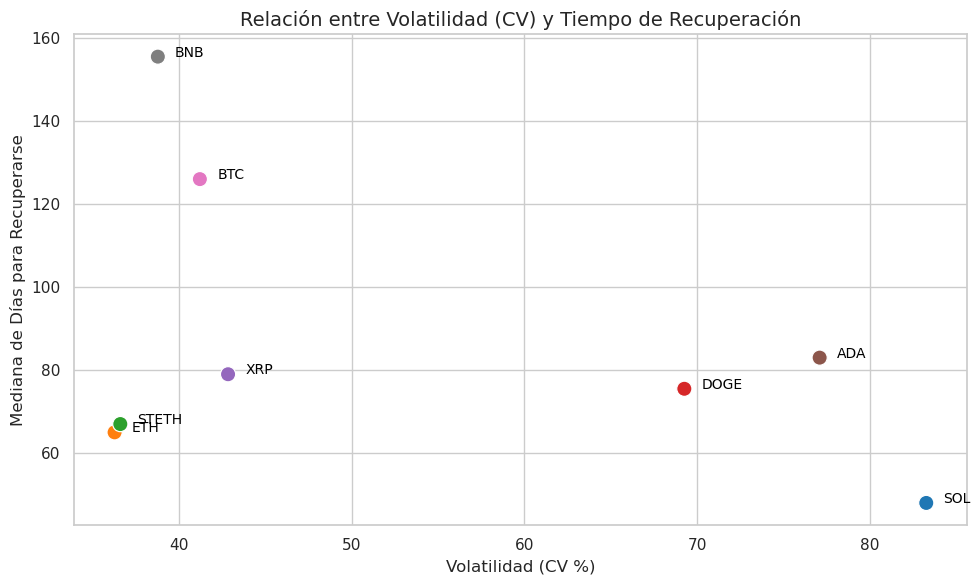

In [ ]:
# --- 1. Función para calcular el tiempo de recuperación ---
def calcular_recuperacion(df_cripto):
    df_cripto = df_cripto.sort_values('Date').reset_index(drop=True) 
    df_cripto['Precio_7d_atras'] = df_cripto['Close'].shift(7) 
    df_cripto['Variacion_7d'] = (df_cripto['Close'] - df_cripto['Precio_7d_atras']) / df_cripto['Precio_7d_atras'] 
    
    # Filtrar días con caída del 15% o más en una semana
    dias_crash = df_cripto[df_cripto['Variacion_7d'] <= -0.15]
    tiempos_recuperacion = []
    # Para cada día de crash, buscamos el primer día posterior donde el precio se recupera al nivel anterior
    for index, row in dias_crash.iterrows(): 
        precio_objetivo = row['Precio_7d_atras']
        fecha_crash = row['Date']
        
        futuro = df_cripto[df_cripto['Date'] > fecha_crash]
        recuperacion = futuro[futuro['Close'] >= precio_objetivo]
        # Si encontramos un día de recuperación, calculamos los días que tardó en recuperarse
        if not recuperacion.empty:
            fecha_recuperacion = recuperacion.iloc[0]['Date']
            dias_tardados = (fecha_recuperacion - fecha_crash).days
            tiempos_recuperacion.append(dias_tardados)
    # Devolvemos la cantidad de crashes, la mediana de días para recuperarse y la recuperación más rápida        
    if tiempos_recuperacion:
        return pd.Series({
            'Cantidad de Crashes (>=15%)': len(dias_crash),
            'Mediana de Recuperacion (Días)': np.median(tiempos_recuperacion),
            'Recuperacion más rápida': np.min(tiempos_recuperacion)
        })
    else:
        return pd.Series({
            'Cantidad de Crashes (>=15%)': len(dias_crash),
            'Mediana de Recuperacion (Días)': np.nan,
            'Recuperacion más rápida': np.nan
        })

# --- 2. Aplicar función y limpiar datos ---
df_recuperacion = df_filtrado.groupby('Simbolo').apply(calcular_recuperacion).reset_index()
# Filtramos Stablecoins ya que no experimentan crashes
df_recuperacion = df_recuperacion[~df_recuperacion['Simbolo'].isin(['USDT', 'USDC'])]
df_recuperacion = df_recuperacion.sort_values(by='Mediana de Recuperacion (Días)').reset_index(drop=True)

print("--- Resiliencia: Mediana de días para recuperarse de una caída del 15% ---")
print(df_recuperacion)
print("\n")

# --- 3. Relación Volatilidad vs Recuperación ---
df_analisis_recuperacion = pd.merge(df_recuperacion, df_volatilidad[['Simbolo', 'CV (%)']], on='Simbolo')

# Evitar que monedas sin datos de recuperación calculen mal la correlación
df_analisis_limpio = df_analisis_recuperacion.dropna(subset=['Mediana de Recuperacion (Días)'])
correlacion_recuperacion = df_analisis_limpio['Mediana de Recuperacion (Días)'].corr(df_analisis_limpio['CV (%)'])

print(f"Correlación entre Mediana de Recuperación y Volatilidad (CV): {correlacion_recuperacion:.2f}")

# --- 4. Gráfico ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CV (%)', y='Mediana de Recuperacion (Días)', data=df_analisis_limpio, hue='Simbolo', palette='tab10', s=120, legend=False)

# Añadir etiquetas de texto
for i in range(df_analisis_limpio.shape[0]):
    plt.text(x=df_analisis_limpio['CV (%)'][i] + 1, 
             y=df_analisis_limpio['Mediana de Recuperacion (Días)'][i], 
             s=df_analisis_limpio['Simbolo'][i], 
             fontdict=dict(color='black', size=10))

plt.title('Relación entre Volatilidad (CV) y Tiempo de Recuperación', fontsize=14)
plt.xlabel('Volatilidad (CV %)', fontsize=12)
plt.ylabel('Mediana de Días para Recuperarse', fontsize=12)
plt.tight_layout()
plt.show()

### Conclusiones sobre Resiliencia y Recuperación

Los datos revelan las siguientes dinámicas:

* **Correlación Inversa (Efecto Rebote):** El cálculo arrojó una correlación de **-0.43** entre el Coeficiente de Variación (volatilidad) y el tiempo de recuperación. Al ser negativa, indica que **las monedas más volátiles tienden a recuperarse más rápido** tras una caída brusca.
* **El Rey de la Volatilidad (SOL):** Solana sufrió la mayor cantidad de crashes del portafolio, con **129 caídas** iguales o peores al 15% semanal. Sin embargo, tiene el récord de resiliencia: su mediana de recuperación es de **48 días**, e incluso registró rebotes completos en un solo día. Cae rápido, pero rebota aún más rápido.
* **La inercia de Bitcoin (BTC):** En el extremo opuesto, Bitcoin demostró ser el activo más estable frente a caídas abruptas, registrando solo **44 eventos** de este tipo. No obstante, cuando BTC sufre un crash de esta magnitud, suele estar asociado a cambios de tendencia a nivel macro (mercados bajistas prolongados), lo que justifica que su mediana de recuperación sea extensa (**126 días**).
* **El caso de BNB:** Binance Coin destaca como el activo con la recuperación más lenta del grupo, tomando una mediana de **155.5 días** en volver a su precio previo al crash.

## Stablecoins como Indicador de Caídas

Otra de las narrativas más comunes entre los analistas es que los grandes inversores (ballenas) suelen refugiarse en stablecoins justo antes de que ocurran caídas drásticas en el mercado. 

En esta sección, intentaremos validar esta hipótesis mediante datos. Analizaremos si un **aumento inusual en el volumen de transacciones de Tether (USDT)** puede actuar como una "señal de alerta temprana" (el día previo) a una caída fuerte de Bitcoin (considerada aquí como una pérdida diaria del 5% o más).

Mediremos el volumen diario de USDT contra su propia media móvil de 20 días. Si el volumen es un 20% (o más) superior a lo normal el día antes de que BTC caiga, lo consideraremos una señal de alerta validada.

--- Análisis de Volumen de USDT previo a caídas de BTC ---
Total de caídas fuertes de BTC detectadas (>5% diario): 77
Veces que el volumen de USDT aumentó >20% el día anterior: 18
Efectividad de la señal: 23.38%



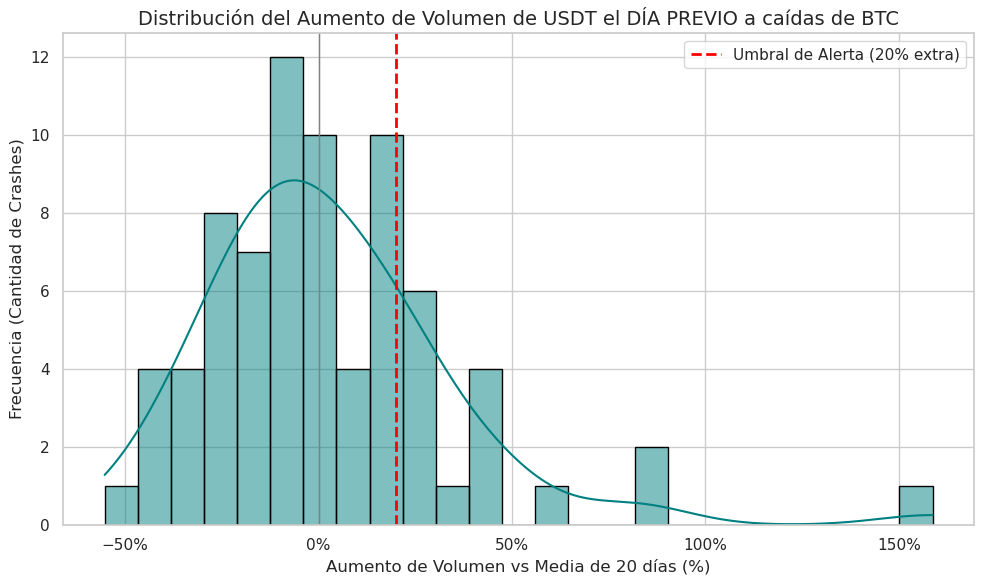

In [9]:
# --- 1. Aislar las caídas fuertes de Bitcoin ---
df_btc = df_filtrado[df_filtrado['Simbolo'] == 'BTC'].copy()
df_btc['Retorno_Diario'] = df_btc['Close'].pct_change()

# Definimos una caída fuerte como -5% en un solo día
umbral_caida = -0.05
dias_crash_btc = df_btc[df_btc['Retorno_Diario'] <= umbral_caida][['Date', 'Retorno_Diario', 'Close']].copy()

# Columna con la fecha del día ANTERIOR a la caída
dias_crash_btc['Date_Previo'] = dias_crash_btc['Date'] - pd.Timedelta(days=1)

# --- 2. Calcular anomalías de volumen en USDT ---
df_usdt = df_filtrado[df_filtrado['Simbolo'] == 'USDT'].copy()

# Media móvil de 20 días para establecer una "línea base" de volumen
df_usdt['Volumen_MA_20'] = df_usdt['Volume'].rolling(window=20).mean()

# Anomalía: cuánto % por encima de la media estuvo el volumen (ej. 0.20 = 20% extra)
df_usdt['Anomalia_Volumen'] = (df_usdt['Volume'] / df_usdt['Volumen_MA_20']) - 1

# --- 3. Cruzar datos (Volumen USDT el día previo vs Crash de BTC) ---
analisis_stable = pd.merge(
    dias_crash_btc, 
    df_usdt[['Date', 'Volume', 'Volumen_MA_20', 'Anomalia_Volumen']], 
    left_on='Date_Previo', 
    right_on='Date', 
    suffixes=('_Crash', '_DiaPrevio')
)

# Definimos el umbral de alerta (20% por encima de la media móvil)
umbral_volumen = 0.20
analisis_stable['Aviso_Volumen'] = analisis_stable['Anomalia_Volumen'] >= umbral_volumen

# --- 4. Resultados ---
total_caidas = len(analisis_stable)
caidas_con_aviso = analisis_stable['Aviso_Volumen'].sum()
porcentaje_aviso = (caidas_con_aviso / total_caidas) * 100

print("--- Análisis de Volumen de USDT previo a caídas de BTC ---")
print(f"Total de caídas fuertes de BTC detectadas (>5% diario): {total_caidas}")
print(f"Veces que el volumen de USDT aumentó >20% el día anterior: {caidas_con_aviso}")
print(f"Efectividad de la señal: {porcentaje_aviso:.2f}%\n")

# --- 5. Gráfico de distribución ---
plt.figure(figsize=(10, 6))
sns.histplot(analisis_stable['Anomalia_Volumen'] * 100, bins=25, kde=True, color='teal', edgecolor='black')

# Marcar el umbral del 20%
plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Umbral de Alerta (20% extra)')
plt.axvline(x=0, color='gray', linestyle='-', linewidth=1) # Línea base (0%)

plt.title('Distribución del Aumento de Volumen de USDT el DÍA PREVIO a caídas de BTC', fontsize=14)
plt.xlabel('Aumento de Volumen vs Media de 20 días (%)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Crashes)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.tight_layout()
plt.show()

### Conclusiones sobre las Stablecoins como Indicador Predictivo

Los resultados obtenidos cuestionan la narrativa de que un aumento de volumen en USDT sirve como alerta temprana de un crash inminente:

* **Baja Efectividad:** El análisis detectó un total de **77 caídas fuertes** de Bitcoin (superiores al 5% diario). De todas ellas, solo en **18 ocasiones** el volumen de USDT aumentó más del 20% el día anterior.
* **Falso Sentimiento de Seguridad:** Esto representa una efectividad de la señal de apenas un **23.38%**. Es decir, en más del 76% de los casos, Bitcoin sufrió una caída sin que las ballenas o el mercado general mostraran un pánico previo medible a través del volumen de Tether.
* **Distribución Normal del Volumen:** El histograma ilustra claramente que la gran mayoría de los eventos se concentran cerca de la marca del 0% (la línea gris), indicando que el volumen del día previo fue simplemente promedio. La línea roja punteada marca nuestro umbral de alerta, y visualmente confirmamos que la mayor parte de las barras se encuentran a la izquierda de la misma. 

En conclusión, usar el volumen de stablecoins como único indicador para predecir caídas a corto plazo no resulta eficiente. Las caídas del mercado suelen ser eventos bruscos que no siempre vienen precedidos de una rotación de capital evidente el día anterior.

## Análisis de Estacionalidad

Una creencia muy arraigada en los mercados financieros tradicionales es la estacionalidad. En esta sección, veremos si el mercado cripto presenta patrones similares. 

Agruparemos los datos por mes y calcularemos el rendimiento promedio histórico (2021-2024) de cada criptomoneda en cada mes del año. Esto nos permitirá visualizar a través de un mapa de calor si hay meses que sistemáticamente presentan rendimientos positivos (verdes) o negativos (rojos).

/tmp/ipykernel_9995/3089043811.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_meses = df_filtrado.groupby(['Simbolo', 'Year', 'Month']).apply(roi_mensual).reset_index(name='ROI_Mensual')


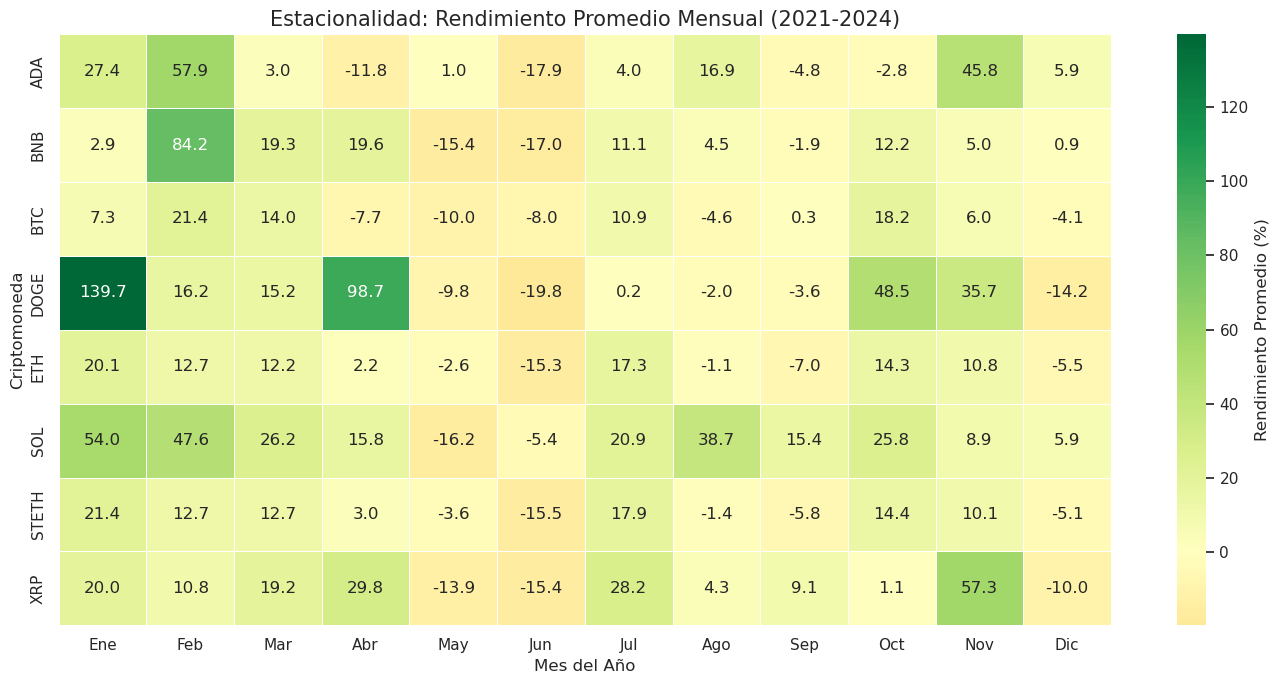

In [10]:
# --- 1. Extraer el Año y Mes ---
df_filtrado['Year'] = df_filtrado['Date'].dt.year
df_filtrado['Month'] = df_filtrado['Date'].dt.month

# --- 2. Función para ROI mensual ---
def roi_mensual(grupo):
    grupo = grupo.sort_values('Date')
    precio_inicio = grupo['Close'].iloc[0]
    precio_fin = grupo['Close'].iloc[-1]
    return ((precio_fin - precio_inicio) / precio_inicio) * 100

# --- 3. Calcular ROI por mes individual y luego el promedio histórico ---
df_meses = df_filtrado.groupby(['Simbolo', 'Year', 'Month']).apply(roi_mensual).reset_index(name='ROI_Mensual')

# Excluir stablecoins (su rendimiento siempre es ~0)
df_meses = df_meses[~df_meses['Simbolo'].isin(['USDT', 'USDC'])]

# Promedio de cada mes a lo largo de los años
estacionalidad = df_meses.groupby(['Simbolo', 'Month'])['ROI_Mensual'].mean().reset_index()

# --- 4. Pivotar para el mapa de calor ---
df_estacionalidad_pivot = estacionalidad.pivot(index='Simbolo', columns='Month', values='ROI_Mensual')

# Cambiar los números (1-12) por nombres de meses
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
df_estacionalidad_pivot.columns = meses_nombres[:len(df_estacionalidad_pivot.columns)]

# --- 5. Visualización ---
plt.figure(figsize=(14, 7))
sns.heatmap(df_estacionalidad_pivot, annot=True, cmap='RdYlGn', center=0, fmt=".1f", 
            linewidths=.5, cbar_kws={'label': 'Rendimiento Promedio (%)'})

plt.title('Estacionalidad: Rendimiento Promedio Mensual (2021-2024)', fontsize=15)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Criptomoneda', fontsize=12)
plt.tight_layout()
plt.show()

### Conclusiones sobre la Estacionalidad del Mercado Cripto

El mapa de calor revela patrones estacionales y valida algunas de las narrativas más populares del ecosistema durante el período 2021-2024:

* **El primer trimestre (Q1) es históricamente alcista:** Los meses de enero, febrero y marzo muestran una clara predominancia del color verde. Destacan explosiones de rentabilidad como el **139.7%** de DOGE en enero o el **84.2%** de BNB en febrero.
* **El efecto en mayo-junio:** Mayo y junio son indiscutiblemente los peores meses del portafolio, teñidos casi por completo de amarillo claro (rendimientos negativos). En junio todas las monedas sufrieron contracciones, destacando caídas de hasta el **-19.8%** en DOGE y **-17.9%** en ADA.
* **El mito de "Uptober":** Octubre valida su apodo en la comunidad cripto. Es un mes de recuperación sólida y generalizada, impulsando fuertes ganancias en DOGE (**48.5%**), SOL (**25.8%**) y BTC (**18.2%**). Este impulso alcista suele extenderse hasta noviembre.
* **Cierre de año moderado:** Diciembre tiende a ser un mes de toma de ganancias o consolidación, mostrando rendimientos mixtos a ligeramente negativos en los principales activos como BTC (**-4.1%**) y ETH (**-5.5%**).
* **Solana (SOL), el activo más constante en verde:** A pesar de su alta volatilidad, SOL es la moneda que presenta la mayor cantidad de meses con promedios positivos a lo largo del año.

## Relación entre Volumen y Volatilidad Intradiaria (Bitcoin)

Por último, aplicaremos la **regresión lineal simple**. Queremos entender si existe una relación predictiva o causal entre la cantidad de dinero que se mueve en un día (Volumen) y la fluctuación del precio durante ese mismo día (Volatilidad Intradiaria).

Aislaremos los datos de Bitcoin (BTC) para evitar distorsiones. Definiremos:
* **Variable Independiente (x):** Volumen Diario de Transacciones.
* **Variable Dependiente (y):** Volatilidad Intradiaria (Porcentaje de variación entre el precio máximo y mínimo del día respecto a la apertura).

Calcularemos el Coeficiente de Correlación (r) y el Coeficiente de Determinación (R²), y trazaremos la recta de regresión para visualizar la tendencia matemática.

--- Relación entre Volumen y Volatilidad Intradiaria (BTC) ---
Coeficiente de correlación (r): 0.6500
Coeficiente de determinación (R²): 0.4225
Función de regresión: y = 9.95e-11 * x + 1.18



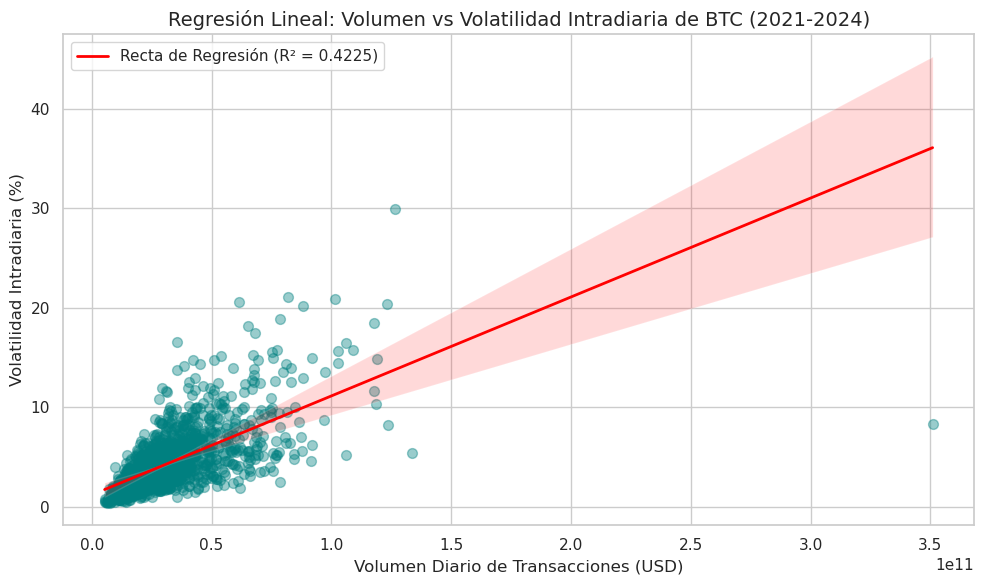

In [11]:
# --- 1. Aislar datos de BTC y calcular volatilidad intradiaria ---
df_btc = df_filtrado[df_filtrado['Simbolo'] == 'BTC'].copy()

# Volatilidad intradiaria: (Máximo - Mínimo) / Apertura * 100
df_btc['Volatilidad_Intradiaria (%)'] = ((df_btc['High'] - df_btc['Low']) / df_btc['Open']) * 100

# --- 2. Definir variables para la regresión ---
x = df_btc['Volume']
y = df_btc['Volatilidad_Intradiaria (%)']

# --- 3. Cálculos estadísticos ---
correlacion = x.corr(y)
res = linregress(x, y)
r_cuadrado = res.rvalue**2

print("--- Relación entre Volumen y Volatilidad Intradiaria (BTC) ---")
print(f"Coeficiente de correlación (r): {correlacion:.4f}")
print(f"Coeficiente de determinación (R²): {r_cuadrado:.4f}")
print(f"Función de regresión: y = {res.slope:.2e} * x + {res.intercept:.2f}\n")

# --- 4. Visualización: Diagrama de Dispersión con Recta de Regresión ---
plt.figure(figsize=(10, 6))

# Usar regplot de seaborn
sns.regplot(
    x=x, 
    y=y, 
    scatter_kws={'alpha': 0.4, 'color': 'teal', 's': 50}, 
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Recta de Regresión (R² = {r_cuadrado:.4f})'}
)

plt.title('Regresión Lineal: Volumen vs Volatilidad Intradiaria de BTC (2021-2024)', fontsize=14)
plt.xlabel('Volumen Diario de Transacciones (USD)', fontsize=12)
plt.ylabel('Volatilidad Intradiaria (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusiones de la Regresión Lineal (Volumen vs Volatilidad)

El modelo confirma la relación entre la actividad comercial y los movimientos de precio en Bitcoin:

* **Correlación Positiva:** El coeficiente de correlación de Pearson ($r = 0.65$) indica una relación moderada. Como dicta la intuición, a medida que aumenta el volumen de dinero transaccionado en un día, la amplitud de los movimientos de precio (volatilidad) también tiende a crecer. 
* **Poder Predictivo ($R^2$):** El coeficiente de determinación es de **0.4225**. Esto significa que el **42.25%** de la volatilidad intradiaria de Bitcoin se explica exclusivamente por la cantidad de volumen operado. Para un activo financiero complejo, es un nivel de explicación significativo, aunque implica que el ~58% restante depende de otros factores (noticias macroeconómicas, sentimiento del mercado, liquidaciones de derivados, etc.).
* **Volatilidad Base:** La función de la recta de regresión ($y = 9.95 \times 10^{-11} \cdot x + 1.18$) nos revela un dato en su ordenada al origen. El valor 1.18 sugiere que, incluso en un escenario teórico de volumen cero o extremadamente bajo, Bitcoin tiene una volatilidad base diaria de aproximadamente **1.18%**.
* **Dispersión (Efecto Abanico):** Visualmente, notamos que a volúmenes bajos, los puntos están muy concentrados cerca de la línea. Sin embargo, a medida que el volumen crece, los puntos se dispersan mucho más.
* **La Anomalía:** Destaca un valor atípico en el extremo derecho del gráfico: un día que registró un volumen masivo (más de $3.5 \times 10^{11}$ USD) pero cuya volatilidad es de aproximadamente el 8%, ubicándose muy por debajo de la recta de regresión. Este tipo de eventos suele corresponder a transacciones internas de exchanges o grandes movimientos Over-The-Counter (OTC) de instituciones, que mueven miles de millones sin impactar el libro de órdenes público.


## Conclusiones

A lo largo del análisis se observaron diferencias muy marcadas entre los distintos criptoactivos, tanto en rentabilidad como en riesgo. En términos generales, el estudio confirma que en el mercado cripto existe una relación entre rendimiento y volatilidad: los activos con mayores ganancias potenciales también suelen ser los más inestables.

Por un lado, criptomonedas como **Solana (SOL)** y **Dogecoin (DOGE)** mostraron los retornos más altos, pero también niveles de riesgo muy elevados. En cambio, **Bitcoin (BTC)** y **Ethereum (ETH)** presentaron comportamientos más moderados, con menor volatilidad relativa y una dinámica más estable. Las **stablecoins** cumplieron su función de resguardo, manteniéndose prácticamente sin variaciones relevantes.

El análisis también permitió identificar que **Bitcoin influye de forma inmediata en gran parte del mercado**, especialmente en las altcoins de mayor capitalización, aunque ese efecto no se prolonga varios días. A su vez, se comprobó que las monedas más volátiles tienden a recuperarse más rápido después de caídas fuertes, lo que sugiere que asumir más riesgo no siempre implica una peor resiliencia.

En cuanto a la predicción de caídas, el volumen de **USDT** no resultó ser una señal suficientemente confiable por sí sola. Del mismo modo, la estacionalidad mostró que ciertos meses tienden a ser más favorables que otros, aunque sin un patrón perfecto para todos los activos. Finalmente, la regresión entre volumen y volatilidad de Bitcoin confirmó una relación positiva moderada, indicando que una mayor actividad operativa suele acompañarse de movimientos de precio más amplios.

En síntesis, el mercado cripto combina **altas oportunidades de ganancia con un riesgo considerable**, por lo que el análisis conjunto de rentabilidad, volatilidad, volumen, estacionalidad y correlaciones resulta clave para interpretar su comportamiento.